In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [11]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

prediction = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

Accuracy: 0.9649122807017544


In [15]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best Cross Validation Score:
0.9626373626373625


In [16]:
param_dist = {
    "n_estimators": [50,100,150,200],
    "max_depth": [5,10,15,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)

random.fit(X_train, y_train)

print("Best Parameters:")
print(random.best_params_)

print("Best Score:")
print(random.best_score_)

Best Parameters:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
Best Score:
0.9604395604395604


In [17]:
best_model = random.best_estimator_

prediction = best_model.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



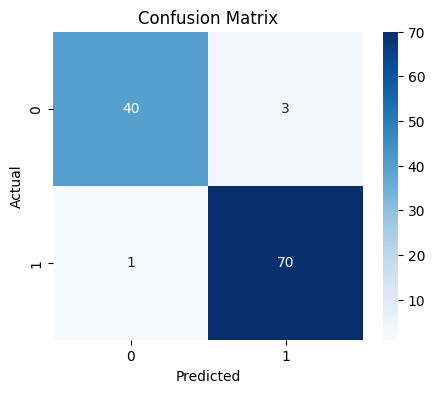

In [18]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
results = pd.DataFrame({
    "Model":[
        "Baseline",
        "GridSearchCV",
        "RandomizedSearchCV"
    ],
    "Accuracy":[
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, grid.best_estimator_.predict(X_test)),
        accuracy_score(y_test, random.best_estimator_.predict(X_test))
    ]
})

print(results)

                Model  Accuracy
0            Baseline  0.964912
1        GridSearchCV  0.964912
2  RandomizedSearchCV  0.964912


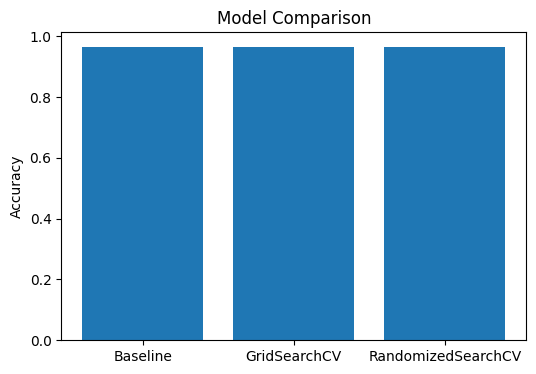

In [20]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()